### [Python Geospatial Tools Every Data Scientist Should Know](https://python.plainenglish.io/6-python-geospatial-tools-every-data-scientist-should-know-no-gis-degree-required-1bde09cf740b)

In [1]:
!pip install -q geopandas folium pysal rasterio shapely h3 pandas matplotlib geodatasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import geopandas as gpd

import folium
import geodatasets

from shapely.geometry import Point, MultiPoint

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load public data: World boundaries, countries, and global cities
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

# I couldn't find the countries data in the geodatasets, and thus I used direct URL instead.
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
countries = gpd.read_file(url)

cities = gpd.read_file(geodatasets.get_path("naturalearth.cities"))

print(f"Loaded {len(cities)} cities across the globe!")
# We got 243 cities in our dataset
cities.head()

Loaded 243 cities across the globe!


,scalerank,natscale,labelrank,featurecla,name,namepar,namealt,nameascii,adm0cap,capalt,...,pop_max,pop_min,pop_other,rank_max,rank_min,meganame,ls_name,min_zoom,ne_id,geometry
0,8,10,3,Admin-0 capital,Vatican City,None,None,Vatican City,1,0,...,832,832,562430,2,2,None,Vatican City,7.0,1159127243,POINT (12.45339 41.90328)
1,7,20,0,Admin-0 capital,San Marino,None,None,San Marino,1,0,...,29579,29000,0,7,7,None,San Marino,6.1,1159146051,POINT (12.44177 43.9361)
2,7,20,0,Admin-0 capital,Vaduz,None,None,Vaduz,1,0,...,36281,5342,33009,7,5,None,Vaduz,6.7,1159146061,POINT (9.51667 47.13372)
3,6,30,8,Admin-0 capital alt,Lobamba,None,None,Lobamba,0,1,...,9782,4557,0,5,4,None,Lobamba,6.0,1159146343,POINT (31.2 -26.46667)
4,6,30,8,Admin-0 capital,Luxembourg,None,None,Luxembourg,1,0,...,107260,76684,106219,9,8,None,Luxembourg,6.0,1159146437,POINT (6.13 49.61166)


<Axes: >

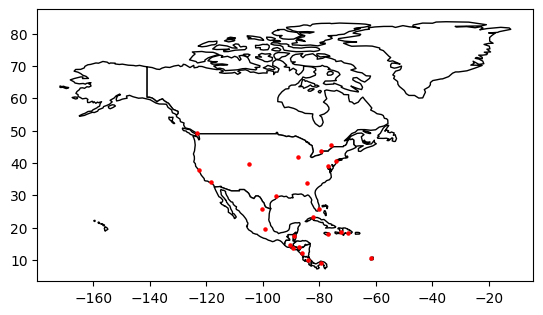

In [4]:
# Geo Spatial Join
cities_with_country = gpd.sjoin(cities, countries, how="inner", predicate="within")

na_cities = cities_with_country[cities_with_country['CONTINENT'] == 'North America']

# Plotting with GeoPandas is as simple as .plot()
ax = countries[countries['CONTINENT'] == 'North America'].plot(color='white', edgecolor='black')
na_cities.plot(ax=ax, color='red', markersize=5)

In [5]:
# Let's create a 5-degree buffer around Paris
paris_point = cities[cities['name'] == 'Paris'].geometry.iloc[0]
paris_buffer = paris_point.buffer(5) # 5 degrees is huge, but good for visibility!

print(f"Paris Point: {paris_point}")
print(f"Area of the 'Paris Zone': {paris_buffer.area}")

Paris Point: POINT (2.3529924615392135 48.85809231626911)
Area of the 'Paris Zone': 78.4137122636485


In [6]:
# 1. Create a GeoDataFrame for the buffer so Folium can read it
buffer_gdf = gpd.GeoDataFrame(geometry=[paris_buffer], crs="EPSG:4324")

# 2. Initialize a Folium map centered on Paris
map = folium.Map(location=[48.8566, 2.3522], zoom_start=5)

# 3. Add the buffer to the map
folium.GeoJson(buffer_gdf).add_to(map)

# 4. Add the original point for context
folium.Marker(location=[48.8566, 2.3522], popup="Paris").add_to(map)

# 5. Show your map
map

In [7]:
cities_per_country = cities_with_country.groupby('NAME').size().reset_index(name='num_cities')
countries_with_city_counts = countries.merge(cities_per_country, left_on='NAME', right_on='NAME', how='left')
countries_with_city_counts['num_cities'] = countries_with_city_counts['num_cities'].fillna(0).astype(int)

# Create a Folium map centered on the world
choropleth_map = folium.Map(location=[0, 0], zoom_start=2)

# Add the choropleth layer
folium.Choropleth(
    geo_data=countries_with_city_counts,
    name='Number of Cities',
    data=countries_with_city_counts,
    columns=['NAME', 'num_cities'],
    key_on='feature.properties.NAME',
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Number of Cities per Country',
    highlight=True,
    tooltip=folium.GeoJsonTooltip(fields=['NAME', 'num_cities'], aliases=['Country', 'Number of Cities'])
).add_to(choropleth_map)

# Display the map
display(choropleth_map)

In [8]:
import h3

# Coordinates for Paris
lat, lng = 48.8566, 2.3522
resolution = 7

# FIX: Change 'geo_to_h3' to 'latlng_to_cell'
hex_id = h3.latlng_to_cell(lat, lng, resolution)

print(f"The H3 address for Paris is: {hex_id}")

The H3 address for Paris is: 871fb4662ffffff


In [9]:
import folium
from shapely.geometry import Polygon

# 1. Get the boundary coordinates (lat, lng) of the hexagon
boundary = h3.cell_to_boundary(hex_id)

# 2. Shapely expects (lng, lat), so we flip them and create a Polygon
hex_polygon = Polygon([ (lng, lat) for lat, lng in boundary ])

# 3. Create a GeoDataFrame
hex_gdf = gpd.GeoDataFrame(geometry=[hex_polygon], crs="EPSG:4326")

# 4. Add it to our map
m = folium.Map(location=[48.8566, 2.3522], zoom_start=12)
folium.GeoJson(hex_gdf, style_function=lambda x: {'fillColor': 'orange', 'color': 'red'}).add_to(m)

display(m)

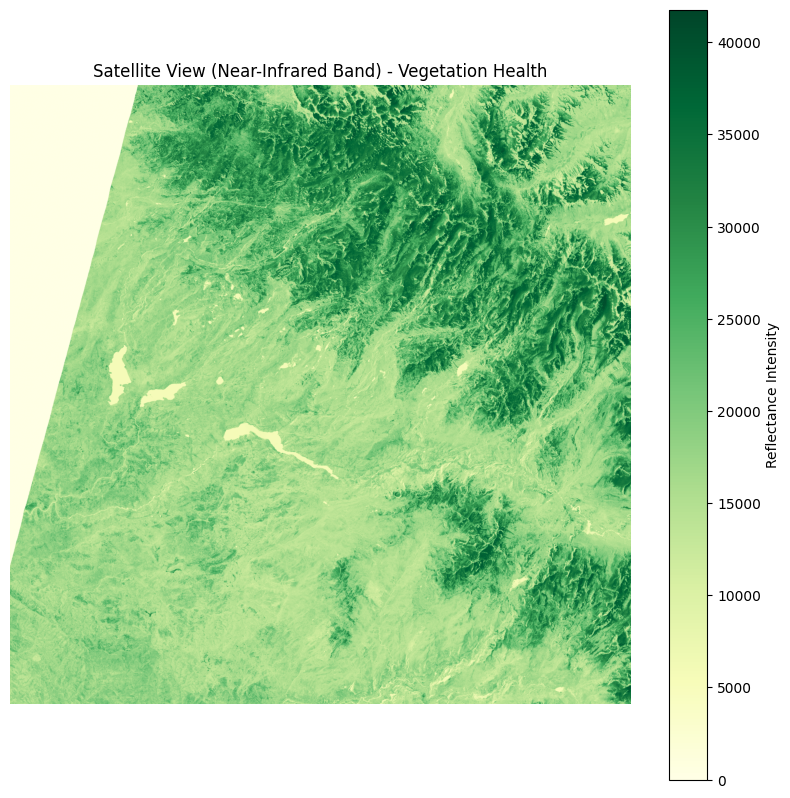

Image Resolution: (30.0, 30.0)


In [10]:
import rasterio
import matplotlib.pyplot as plt
from rasterio.plot import show
import numpy as np

# We'll use a public URL for a Landsat 8 satellite image (Near-Infrared band)
# This is a real satellite image hosted by Google Cloud
raster_url = "https://storage.googleapis.com/gcp-public-data-landsat/LC08/01/042/034/LC08_L1TP_042034_20170616_20170629_01_T1/LC08_L1TP_042034_20170616_20170629_01_T1_B5.TIF"

with rasterio.open(raster_url) as src:
    # Read the data (band 1)
    # We only read a small 'window' to keep it fast in Colab
    window = rasterio.windows.Window(1000, 1000, 2000, 2000)
    data = src.read(1, window=window)

    # Visualize
    plt.figure(figsize=(10, 10))
    plt.title("Satellite View (Near-Infrared Band) - Vegetation Health")
    # Using 'YlGn' (Yellow-Green) colormap to highlight vegetation
    plt.imshow(data, cmap='YlGn')
    plt.colorbar(label='Reflectance Intensity')
    plt.axis('off')
    plt.show()

    # Show basic metadata
    print(f"Image Resolution: {src.res}")

Moran's I Statistic: 0.5002
P-value: 0.0010


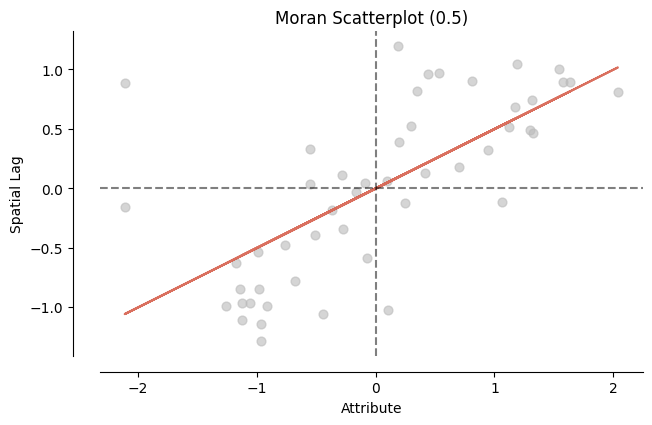

In [11]:
import libpysal
from esda.moran import Moran
from splot.esda import moran_scatterplot
import matplotlib.pyplot as plt

# 1. We'll use a built-in PySAL dataset of Columbus, Ohio neighborhoods
path = libpysal.examples.get_path('columbus.shp')
columbus = gpd.read_file(path)

# 2. Define 'Neighbors' (Spatial Weights)
# This tells Python that neighborhoods touching each other should be compared
w = libpysal.weights.Queen.from_dataframe(columbus)
w.transform = 'R' # Row-standardize

# 3. Calculate Moran's I for 'CRIME' (Is crime spatially clustered?)
y = columbus['CRIME']
moran = Moran(y, w)

print(f"Moran's I Statistic: {moran.I:.4f}")
print(f"P-value: {moran.p_sim:.4f}")

# 4. Visualize the "Spatial Lag"
# This shows how a neighborhood's crime relates to its neighbors' crime
moran_scatterplot(moran, aspect_equal=True)
plt.show()